Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.3
    ),
    transforms.RandomHorizontalFlip(p=0.35),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  34


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  8


### Using Model Architecture:
* 3 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

In [7]:
model.add(
    # First Layer
    nn.Conv2d(3, 12, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(12),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    # Second Layer
    nn.Conv2d(12, 24, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(24),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    # Third Layer
    nn.Conv2d(24, 48, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(48),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    # Flatten
    nn.Flatten(),

    # Fully connected layer (for 64x64 input)
    nn.Linear(48 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

Architecture(
  (blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (10): ReLU()
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): Flatten(start_dim=1, end_dim=-1)
      (13): Linear(in_features=3072, out_featu

### Use Trainer to train and check validations

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()

In [9]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment1/",
    save_checkpoints=1,
    print_every=10
    )

In [10]:
history = trainer.fit(100)

Epoch [10/100] | Train Loss: 0.5297 | Val Loss: 0.8802 | Train Acc: 0.7793 | Val Acc: 0.6991 | Train F1: 0.7799 | Val F1: 0.6980
Epoch [20/100] | Train Loss: 0.5189 | Val Loss: 1.2838 | Train Acc: 0.7973 | Val Acc: 0.4889 | Train F1: 0.7985 | Val F1: 0.4371
Epoch [30/100] | Train Loss: 0.3756 | Val Loss: 2.2958 | Train Acc: 0.8540 | Val Acc: 0.4336 | Train F1: 0.8550 | Val F1: 0.3641
Epoch [40/100] | Train Loss: 0.2585 | Val Loss: 0.8168 | Train Acc: 0.9022 | Val Acc: 0.7566 | Train F1: 0.9027 | Val F1: 0.7525
Epoch [50/100] | Train Loss: 0.2010 | Val Loss: 0.6932 | Train Acc: 0.9310 | Val Acc: 0.7765 | Train F1: 0.9314 | Val F1: 0.7740
Epoch [60/100] | Train Loss: 0.2054 | Val Loss: 0.8297 | Train Acc: 0.9286 | Val Acc: 0.7788 | Train F1: 0.9293 | Val F1: 0.7788
Epoch [70/100] | Train Loss: 0.1246 | Val Loss: 7.3174 | Train Acc: 0.9622 | Val Acc: 0.4558 | Train F1: 0.9623 | Val F1: 0.3990
Epoch [80/100] | Train Loss: 0.0972 | Val Loss: 0.7572 | Train Acc: 0.9683 | Val Acc: 0.8142 | Tr

### Save Metrics

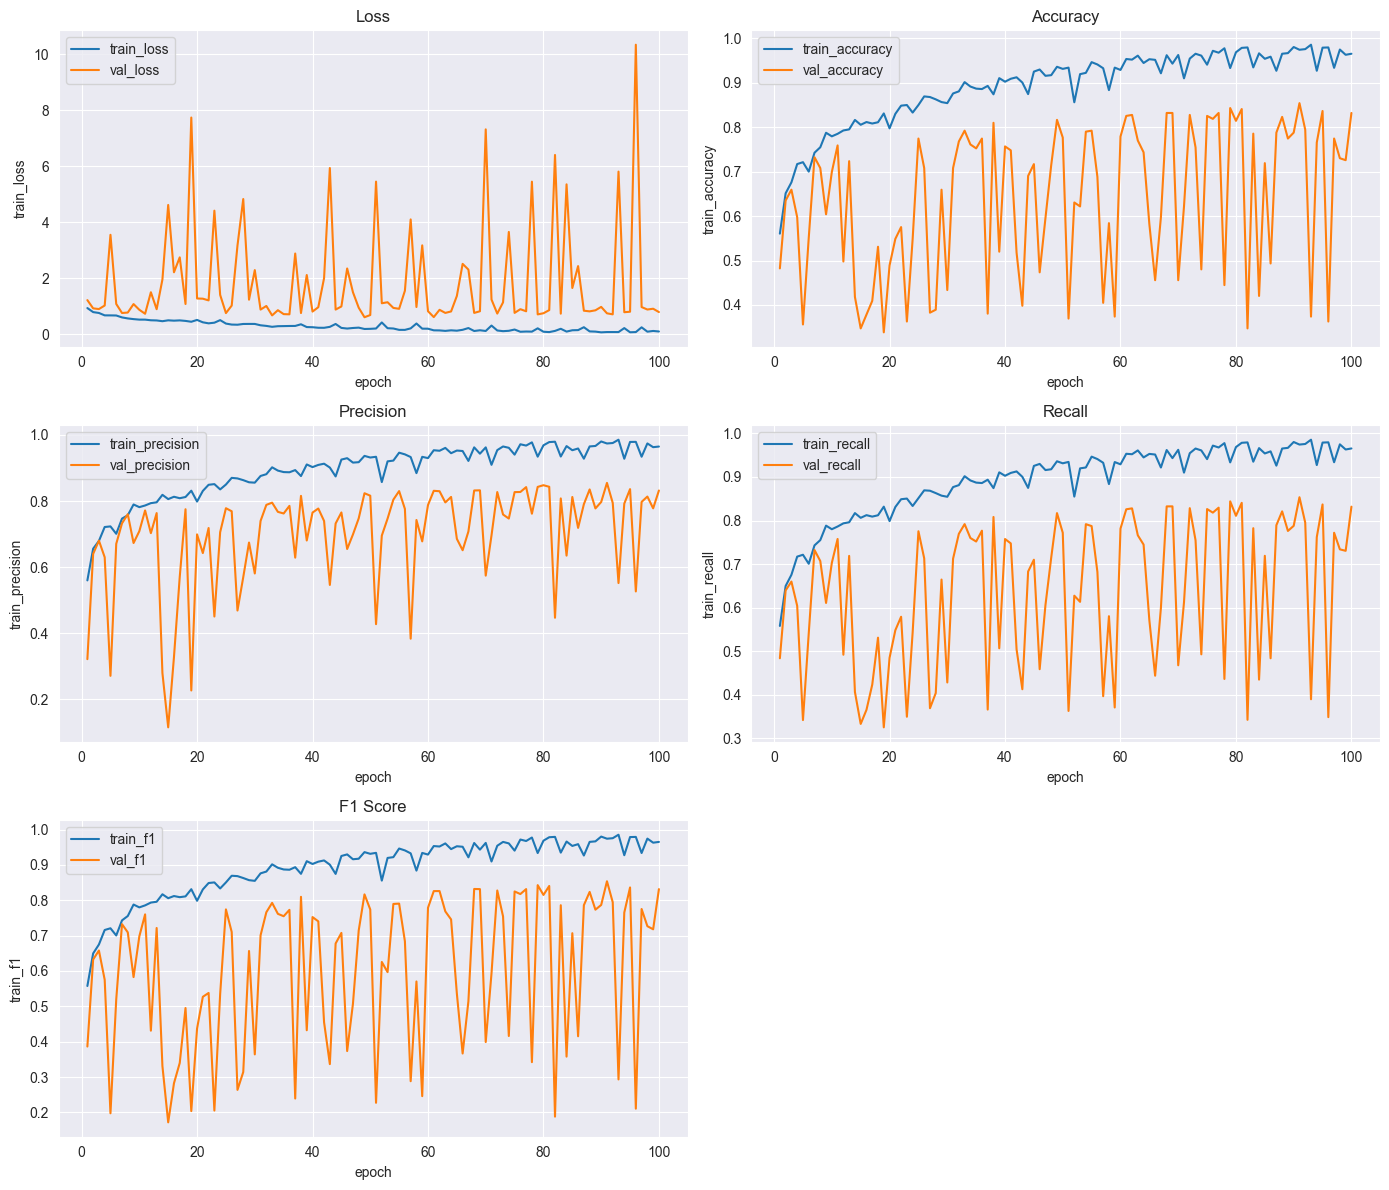

In [11]:
df = plot_training_metrics(history)
df.to_csv("../documentations/resources/experiment1/tables/training_metrics.csv", index=False)

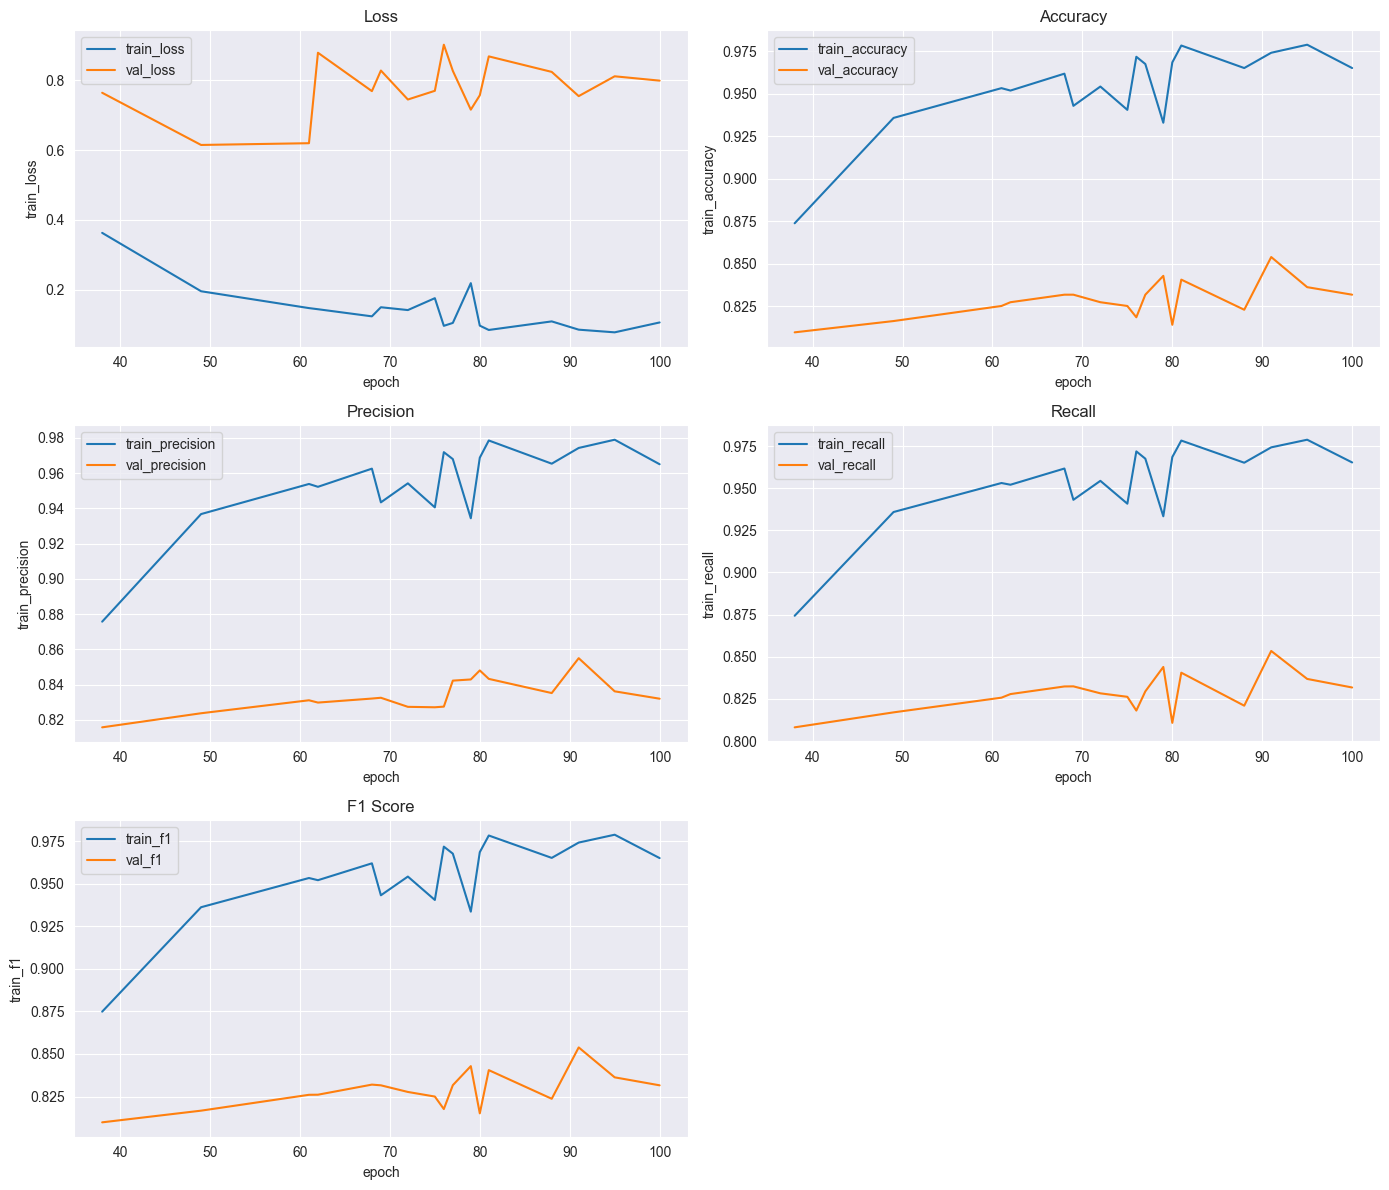

In [12]:
filtered_df = df[
    (df["val_accuracy"] >= 0.8) &
    (df["val_f1"] >= 0.8)
].to_dict()

high_accuracy_df = plot_training_metrics(filtered_df)

### Overall training & validation behaviour
* Training loss shows a strong overall decreasing trend from ~0.94 (epoch 1) to ~0.08–0.10 range in later epochs, indicating consistent optimization and learning of representations.
* Training metrics (accuracy, precision, recall, F1) steadily improve over time, moving from ~0.56 accuracy early to >0.95–0.98 in later epochs, showing strong convergence.
* Validation metrics improve more slowly and are significantly noisier, with clear fluctuations across epochs rather than monotonic improvement.
* Several epochs show sharp validation degradation (e.g., epochs 5, 14, 19, 43, 51, 82, 96), indicating instability and occasional overfitting or poor generalization.
* Best validation performance tends to cluster in the mid-to-late training phase (roughly epochs 75–92).
* Confusion matrices indicate early heavy class collapse (predicting single class) which gradually improves into more balanced class separation in later epochs.
* After peak performance (~epoch 91), validation performance becomes inconsistent again, suggesting late-stage overfitting or training instability.

### Summary 
The model shows stable and effective learning on the training set, with steadily decreasing loss and consistently increasing accuracy and F1-score across epochs. However, validation performance is notably less stable, with periodic sharp drops indicating overfitting at multiple stages. Despite this noise, validation metrics improve significantly in the second half of training, where the model achieves its best generalization. The learning process ultimately converges well, but with clear sensitivity to overfitting after peak performance, suggesting that early stopping around the best validation window would be optimal.

<b>Best Epoch 91</b>

<b>Loss</b>
* Train Loss = 0.0857267208835658
* Valid Loss = 0.7548888362944126

<b>Training Metrics</b>
* Train Accuracy = 0.9740075469017029
* Train Precison = 0.9742057919502258
* Train Recall = 0.9742608070373535
* Train F1 = 0.9742177128791809

<b>Validation Accuracy</b>
* Validation Accuracy = 0.8539823293685913
* Validation Precision = 0.8549745082855225
* Validation Recall = 0.853439867496491
* Validation F1 = 0.8538417220115662

## Use Tester Module to Test Model

Load Model with State Dict

In [13]:
import copy

test_scores = []

# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

# Loops for testing
for i in range(100):
    test_model = copy.deepcopy(model)

    checkpoint = torch.load(
        f"../models/experiment1/model_epoch_{i+1}.pt",
        map_location="cuda"
    )

    test_model.load_state_dict(checkpoint["model"])

    tester = Tester(
        test_model,
        test_loader,
        3,
        torch.nn.CrossEntropyLoss(),
        "cuda"
    )

    result = tester.test(return_predictions=True)

    test_scores.append(result)


### Save Test Metrics

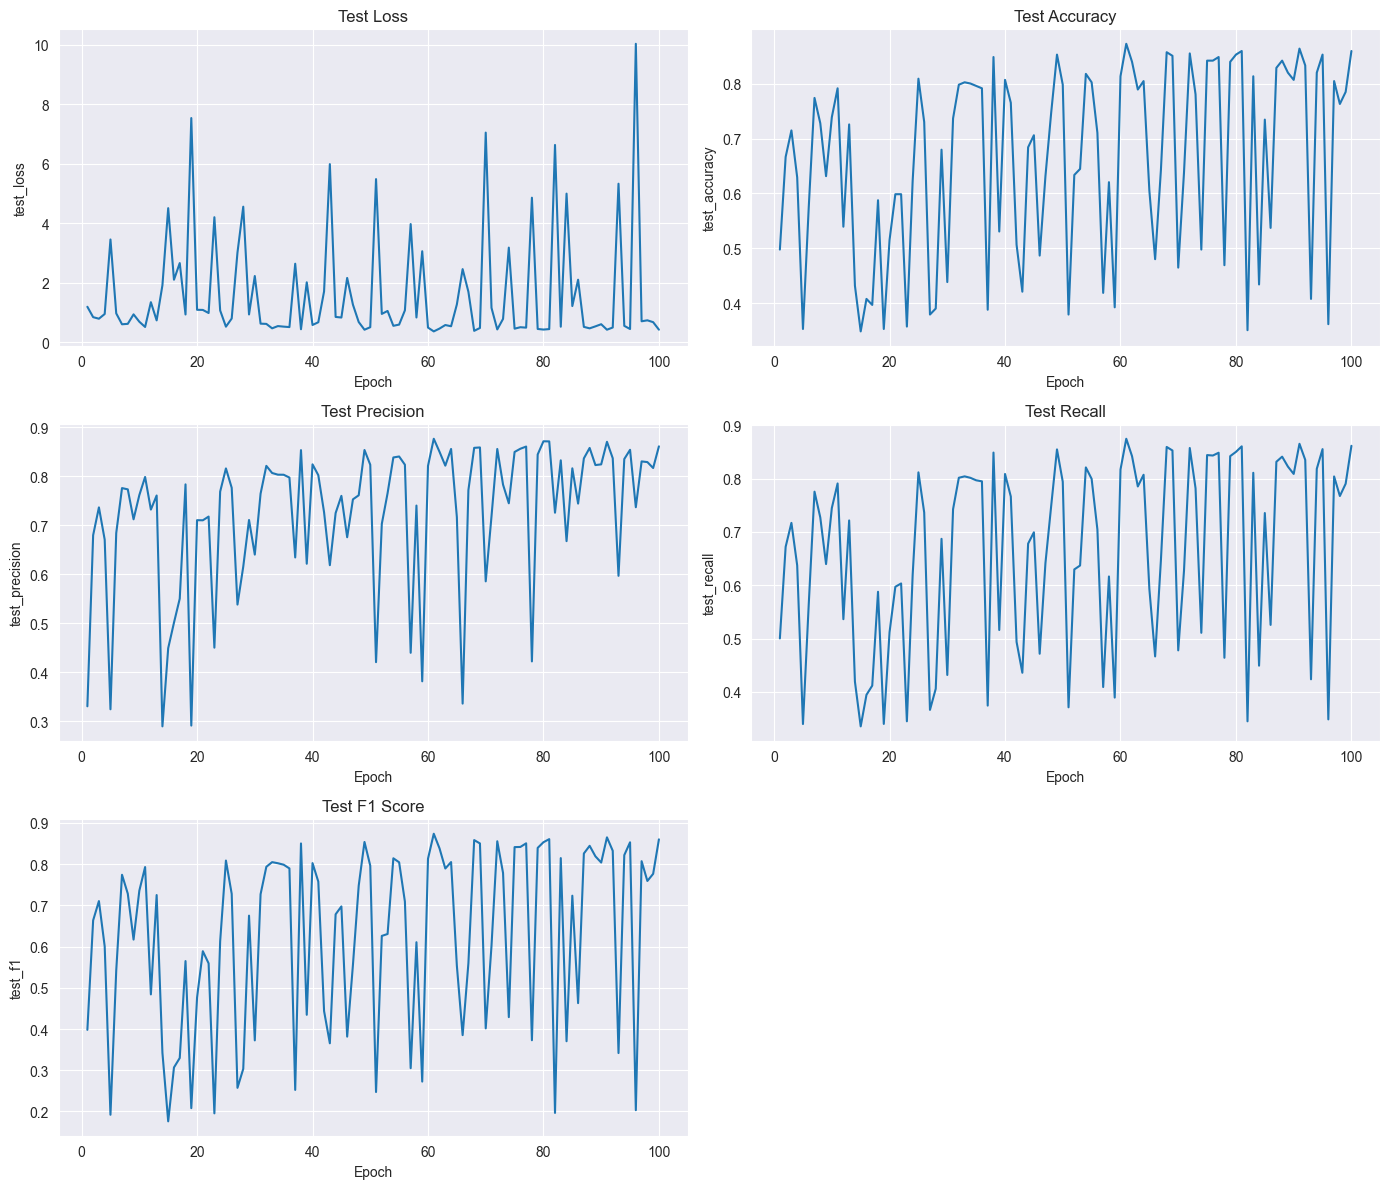

In [14]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/resources/experiment1/tables/test_metrics.csv", index=False)

### Test Performance Trend (100 epochs)
The test metrics show high volatility in early epochs followed by gradual stabilization in the mid-training range, with clear performance improvements up to roughly epochs 60–90. Early epochs (1–20) are unstable, with low accuracy, inconsistent precision/recall balance, and occasional collapse in F1 (e.g., epoch 5 and 15). From around epoch 25 onward, performance becomes more consistent, with accuracy frequently in the 0.78–0.86 range and improved F1 stability. Several strong peaks appear in the later half of training (notably epochs 68–77 and 91–100 range), where metrics stabilize around high 0.83–0.86 accuracy with balanced precision and recall. However, there are intermittent sharp drops (e.g., epochs 82, 93, 96), indicating occasional overfitting or optimization instability. Overall, the model converges well, but generalization fluctuates significantly depending on checkpoint.

<b>Best Epoch 91</b>

* Loss = 0.4224052373319864
* Accuracy = 0.8640350699424744
* Precision = 0.870095431804657
* Recall = 0.8652940392494202
* F1-Score = 0.864971399307251